In [48]:
import polars as pl
import numpy as np
import matplotlib.pyplot as plt
import sklearn
from pathlib import Path
import pandas as pd


In [42]:
base_path = Path("..")
train_path = base_path/"data"/"raw"/"train.csv"
test_path = base_path/"data"/"raw"/"test.csv"



In [43]:
train_df = pl.read_csv(train_path)
print(train_df.head())
print(train_df.shape)
print(train_df.schema)
train_df.columns


shape: (5, 15)
┌─────┬─────┬─────────────┬─────────────┬───┬─────────────┬─────────────┬─────────────┬────────────┐
│ id  ┆ Age ┆ Annual_Inco ┆ Daily_Commu ┆ … ┆ Home_Chargi ┆ Subsidy_Ava ┆ Range_Anxie ┆ Will_Buy_E │
│ --- ┆ --- ┆ me_USD      ┆ te_km       ┆   ┆ ng_Possible ┆ ilable      ┆ ty_Level    ┆ V          │
│ i64 ┆ i64 ┆ ---         ┆ ---         ┆   ┆ ---         ┆ ---         ┆ ---         ┆ ---        │
│     ┆     ┆ f64         ┆ f64         ┆   ┆ str         ┆ str         ┆ str         ┆ str        │
╞═════╪═════╪═════════════╪═════════════╪═══╪═════════════╪═════════════╪═════════════╪════════════╡
│ 0   ┆ 66  ┆ 92887.0     ┆ 23.4        ┆ … ┆ Yes         ┆ No          ┆ Low         ┆ No         │
│ 1   ┆ 38  ┆ 30000.0     ┆ 5.0         ┆ … ┆ Yes         ┆ No          ┆ Low         ┆ No         │
│ 2   ┆ 26  ┆ 94389.0     ┆ 36.8        ┆ … ┆ No          ┆ Yes         ┆ Low         ┆ Yes        │
│ 3   ┆ 66  ┆ 73580.0     ┆ 23.7        ┆ … ┆ Yes         ┆ No          ┆ Lo

['id',
 'Age',
 'Annual_Income_USD',
 'Daily_Commute_km',
 'Number_of_Cars_Owned',
 'Charging_Stations_Near_Home',
 'Charging_Stations_Near_Work',
 'Environmental_Concern_Level',
 'Gender',
 'City_Type',
 'Current_Car_Type',
 'Home_Charging_Possible',
 'Subsidy_Available',
 'Range_Anxiety_Level',
 'Will_Buy_EV']

In [44]:
train_df.describe()

statistic,id,Age,Annual_Income_USD,Daily_Commute_km,Number_of_Cars_Owned,Charging_Stations_Near_Home,Charging_Stations_Near_Work,Environmental_Concern_Level,Gender,City_Type,Current_Car_Type,Home_Charging_Possible,Subsidy_Available,Range_Anxiety_Level,Will_Buy_EV
str,f64,f64,f64,f64,f64,f64,f64,f64,str,str,str,str,str,str,str
"""count""",668665.0,668665.0,668665.0,668665.0,668665.0,668665.0,668665.0,668665.0,"""668665""","""668665""","""668665""","""668665""","""668665""","""668665""","""668665"""
"""null_count""",0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,"""0""","""0""","""0""","""0""","""0""","""0""","""0"""
"""mean""",334332.0,47.039171,84769.266989,32.158298,1.712626,4.960408,7.176314,2.935477,null,null,null,null,null,null,null
"""std""",193027.103211,12.875448,28648.029042,18.730474,0.729275,3.926843,5.186627,1.429119,null,null,null,null,null,null,null
"""min""",0.0,25.0,30000.0,5.0,1.0,0.0,0.0,1.0,"""Female""","""Rural""","""Hatchback""","""No""","""No""","""High""","""No"""
"""25%""",167166.0,36.0,67376.0,17.2,1.0,2.0,3.0,2.0,null,null,null,null,null,null,null
"""50%""",334332.0,47.0,84880.0,33.6,2.0,4.0,6.0,3.0,null,null,null,null,null,null,null
"""75%""",501498.0,58.0,102753.0,47.4,2.0,7.0,10.0,4.0,null,null,null,null,null,null,null
"""max""",668664.0,69.0,188549.0,98.7,4.0,14.0,19.0,5.0,"""Other""","""Urban""","""Truck""","""Yes""","""Yes""","""Medium""","""Yes"""


In [45]:
train_df.null_count()

id,Age,Annual_Income_USD,Daily_Commute_km,Number_of_Cars_Owned,Charging_Stations_Near_Home,Charging_Stations_Near_Work,Environmental_Concern_Level,Gender,City_Type,Current_Car_Type,Home_Charging_Possible,Subsidy_Available,Range_Anxiety_Level,Will_Buy_EV
u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32
0,0,0,0,0,0,0,0,0,0,0,0,0,0,0


In [46]:
train_df["Will_Buy_EV"].value_counts()
552886 / (552886 + 116779)

0.8256157929711124

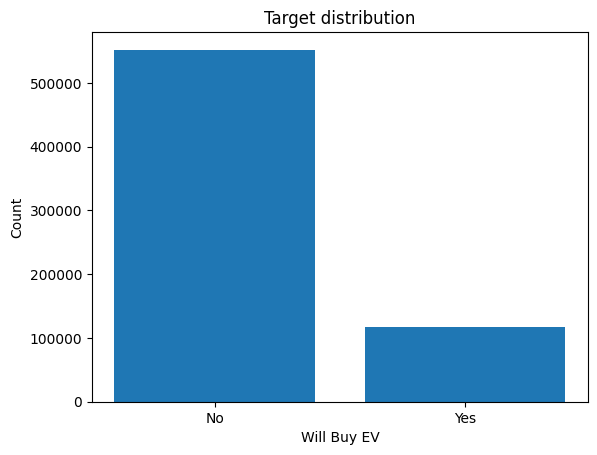

In [54]:
target_counts = train_df["Will_Buy_EV"].value_counts()

plt.bar(
    target_counts["Will_Buy_EV"].to_list(),
    target_counts["count"].to_list()
)

plt.xlabel("Will Buy EV")
plt.ylabel("Count")
plt.title("Target distribution")
plt.show()

#### Disbalance
Classes have significant disbalance (if the model determines all the points as the class "NO", then accuracy will be about 82.5%)
Then the best way is to use other metrics


In [52]:
numeric_features = [
    "Age",
    "Annual_Income_USD",
    "Daily_Commute_km",
    "Number_of_Cars_Owned",
    "Charging_Stations_Near_Home",
    "Charging_Stations_Near_Work",
    "Environmental_Concern_Level",
    "Range_Anxiety_Level"
]

categorical_features = [
    "Gender",
    "City_Type",
    "Current_Car_Type",
    "Home_Charging_Possible",
    "Subsidy_Available"
]

In [ ]:
binary_cols = [
    "Home_Charging_Possible",
    "Subsidy_Available",
    "Will_Buy_EV"
]

for col in binary_cols:
    print(col)
    print(train_df[col].unique())

train_df = train_df.with_columns(
    [
        pl.col(col)
        .replace({"Yes": 1, "No": 0})
        .cast(pl.Int8)
        .alias(col)
        for col in binary_cols
    ]
)

Home_Charging_Possible
shape: (2,)
Series: 'Home_Charging_Possible' [str]
[
	"Yes"
	"No"
]
Subsidy_Available
shape: (2,)
Series: 'Subsidy_Available' [str]
[
	"Yes"
	"No"
]


In [74]:
print(col, train_df["Gender"].unique())

Age_Group shape: (3,)
Series: 'Gender' [str]
[
	"Other"
	"Male"
	"Female"
]


In [64]:
train_df = train_df.with_columns(
    pl.col("Age").cut(
        breaks=[25, 35, 45, 55, 65],
        labels=["до 25", "25-35", "35-45", "45-55", "55-65", "65+"]
    ).alias("Age_Group")
)

In [66]:
age_buy_rate = (
    train_df
    .group_by("Age_Group")
    .agg(
        pl.col("Will_Buy_EV").mean().alias("buy_rate"),
        pl.len().alias("count")
    )
)

In [67]:
age_buy_rate = (
    train_df
    .group_by("Age_Group")
    .agg(
        pl.col("Will_Buy_EV").mean().alias("buy_rate")
    )
    .sort("Age_Group")
)

print(age_buy_rate)

shape: (6, 2)
┌───────────┬──────────┐
│ Age_Group ┆ buy_rate │
│ ---       ┆ ---      │
│ enum      ┆ f64      │
╞═══════════╪══════════╡
│ до 25     ┆ 0.144527 │
│ 25-35     ┆ 0.180849 │
│ 35-45     ┆ 0.167762 │
│ 45-55     ┆ 0.189775 │
│ 55-65     ┆ 0.166222 │
│ 65+       ┆ 0.163987 │
└───────────┴──────────┘


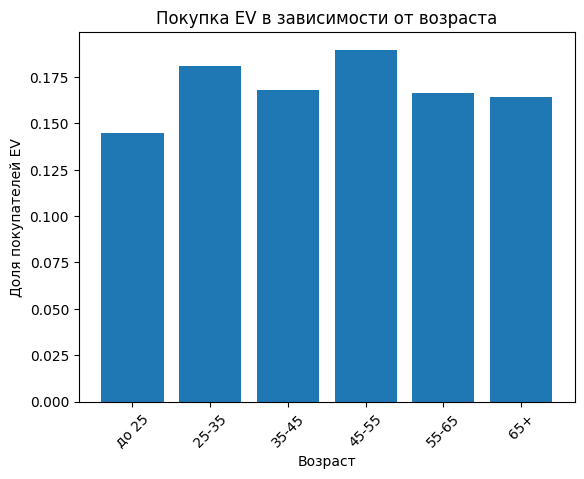

In [68]:
plt.bar(
    age_buy_rate["Age_Group"].to_list(),
    age_buy_rate["buy_rate"].to_list()
)

plt.xlabel("Возраст")
plt.ylabel("Доля покупателей EV")
plt.title("Покупка EV в зависимости от возраста")
plt.xticks(rotation=45)
plt.show()

#### артем, как доделаешь еда, напиши тут в мд ключевое по данным, я пока модель начну